In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.linear_model import ElasticNetCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_percentage_error, r2_score
from sklearn.model_selection import TimeSeriesSplit
import pickle
import os

DATA_PROC = os.path.join('..', 'data', 'processed')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False

df = pd.read_csv(os.path.join(DATA_PROC, 'dataset_maestro_semanal.csv'),
                 parse_dates=['fecha'])

print(f"Dataset semanal: {df.shape}")
print(f"Semanas: {len(df)}  |  Nulos: {df.isnull().sum().sum()}")
print(f"Venta semanal media: {df['venta_neta_eur'].mean():,.0f}€  std: {df['venta_neta_eur'].std():,.0f}€")


Dataset semanal: (262, 29)
Semanas: 262  |  Nulos: 0
Venta semanal media: 2,931,642€  std: 718,998€


In [16]:
# 4 bloques estratégicos y transformación suavizante para saturación

df['bloque_digital_perf']      = df['ads_paid_search'] + df['ads_social_paid']
df['bloque_digital_awareness'] = df['ads_display'] + df['ads_video_online']
df['bloque_offline']           = df['ads_exterior'] + df['ads_prensa'] + df['ads_radio_local']
df['bloque_crm']               = df['ads_email_crm']

BLOQUES_RAW = ['bloque_digital_perf', 'bloque_digital_awareness',
               'bloque_offline', 'bloque_crm']
BLOQUES_X = [f'x_{b}' for b in BLOQUES_RAW]

for b in BLOQUES_RAW:
    df[f'x_{b}'] = np.log1p(df[b].clip(lower=0))

print("Bloques creados (raw + log1p):")
for b in BLOQUES_RAW:
    print(f"  {b:<30} media raw: {df[b].mean():,.0f} | media log1p: {df[f'x_{b}'].mean():.2f}")


Bloques creados (raw + log1p):
  bloque_digital_perf            media raw: 139,187 | media log1p: 11.77
  bloque_digital_awareness       media raw: 122,574 | media log1p: 11.62
  bloque_offline                 media raw: 153,118 | media log1p: 11.84
  bloque_crm                     media raw: 13,980 | media log1p: 9.47


In [17]:
TARGET = 'venta_neta_eur'

VARS_CALENDARIO = ['fin_de_semana', 'payday_flag', 'rebajas_flag',
                   'black_friday_flag', 'navidad_flag', 'semana_santa_flag',
                   'vacaciones_flag', 'festivo_local_flag',
                   'temperatura_media_c', 'lluvia_indice', 'turismo_indice',
                   'incidencia_ecommerce']
VARS_TRAFICO = ['sesiones_web', 'conv_web_pct', 'visitas_tienda', 'pedidos_online']

for yr in [2021, 2022, 2023, 2024]:
    df[f'dummy_{yr}'] = (df['fecha'].dt.year >= yr).astype(int)

BASE_FEATURES  = ['tendencia', 'dummy_2021', 'dummy_2022', 'dummy_2023', 'dummy_2024'] + VARS_CALENDARIO
MEDIA_FEATURES = BLOQUES_X

df_model = df[df['fecha'] >= '2020-01-01'].copy().reset_index(drop=True)
train_mask = df_model['fecha'] < '2024-01-01'
test_mask  = df_model['fecha'] >= '2024-01-01'

def fit_two_stage(train_df, pred_df):
    # Etapa 1: base estructural (sin medios)
    scaler_base = StandardScaler()
    Xb_train = scaler_base.fit_transform(train_df[BASE_FEATURES])
    y_train  = train_df[TARGET].values

    model_base = ElasticNetCV(
        l1_ratio     = [0.01, 0.05, 0.1, 0.2, 0.3, 0.5],
        alphas       = np.logspace(-3, 4, 60),
        cv           = TimeSeriesSplit(n_splits=4),
        max_iter     = 25000,
        random_state = 42
    )
    model_base.fit(Xb_train, y_train)

    base_train_pred = np.maximum(model_base.predict(Xb_train), 0)
    resid_train = np.maximum(y_train - base_train_pred, 0)

    # Etapa 2: componente incremental de marketing con coeficientes no negativos
    scaler_media = StandardScaler()
    Xm_train = scaler_media.fit_transform(train_df[MEDIA_FEATURES])

    model_media = ElasticNetCV(
        l1_ratio     = [0.05, 0.1, 0.2, 0.3, 0.5, 0.7, 0.9],
        alphas       = np.logspace(-4, 3, 80),
        cv           = TimeSeriesSplit(n_splits=4),
        max_iter     = 25000,
        random_state = 42,
        positive     = True
    )
    model_media.fit(Xm_train, resid_train)

    Xb_pred = scaler_base.transform(pred_df[BASE_FEATURES])
    Xm_pred = scaler_media.transform(pred_df[MEDIA_FEATURES])

    base_pred  = np.maximum(model_base.predict(Xb_pred), 0)
    media_pred = np.maximum(model_media.predict(Xm_pred), 0)
    total_pred = base_pred + media_pred

    return {
        'model_base': model_base,
        'scaler_base': scaler_base,
        'model_media': model_media,
        'scaler_media': scaler_media,
        'base_pred': base_pred,
        'media_pred': media_pred,
        'total_pred': total_pred,
        'resid_train': resid_train,
    }

print("Modelo de dos etapas preparado:")
print("  Etapa 1 → base estructural sin medios")
print("  Etapa 2 → incremental de marketing con coeficientes no negativos")
print("\nVariables excluidas del MMM por fuga/mediación:")
for v in VARS_TRAFICO:
    print(f"  {v}")
print(f"\nBase features:  {len(BASE_FEATURES)}")
print(f"Media features: {len(MEDIA_FEATURES)}")
print(f"Total semanas:  {len(df_model)}")


Modelo de dos etapas preparado:
  Etapa 1 → base estructural sin medios
  Etapa 2 → incremental de marketing con coeficientes no negativos

Variables excluidas del MMM por fuga/mediación:
  sesiones_web
  conv_web_pct
  visitas_tienda
  pedidos_online

Base features:  17
Media features: 4
Total semanas:  261


MAPE y R² por bloque temporal:
  Bloque 1 (desde 2020-11-24): MAPE=29.11%  R²=-7.1532
  Bloque 2 (desde 2021-09-21): MAPE=3.56%  R²=0.6546
  Bloque 3 (desde 2022-07-19): MAPE=1.16%  R²=0.8936
  Bloque 4 (desde 2023-05-16): MAPE=2.18%  R²=0.4540
  Bloque 5 (desde 2024-03-12): MAPE=15.40%  R²=-0.1082

MAPE medio CV total:    10.28% ± 10.72%
MAPE medio CV ex-COVID: 5.57%
R² medio CV ex-COVID:   0.4735
R² medio CV total:      -1.0518

Holdout 2024:
  MAPE holdout: 18.11%
  R² holdout:   -0.3089

MAPE total (in-sample, referencia): 0.86%
R² total (in-sample, referencia):   0.9973


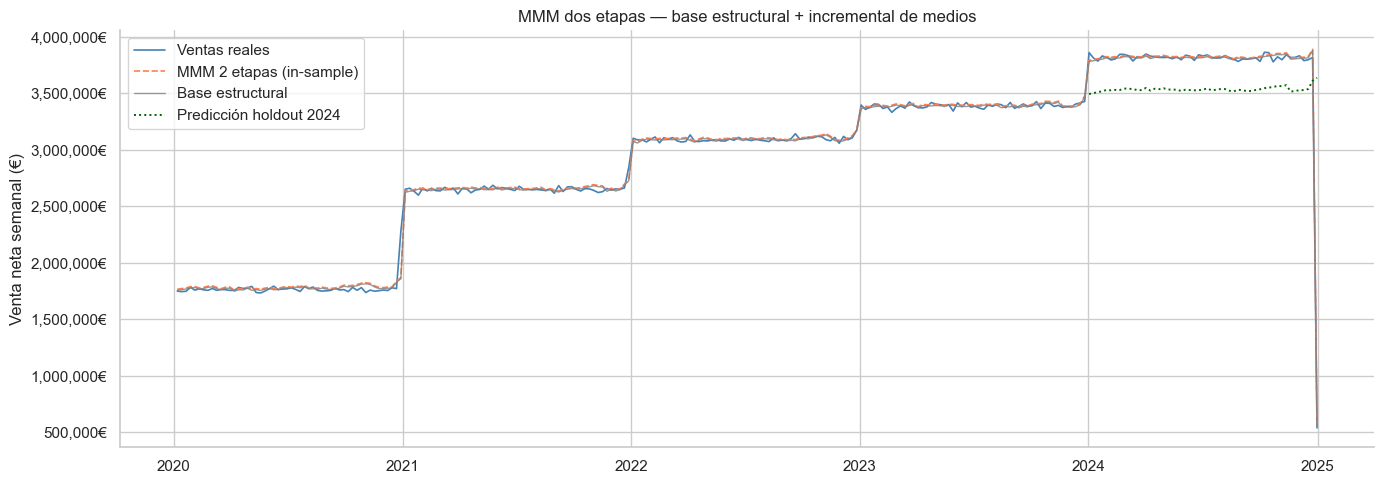

In [18]:
# Validación cruzada temporal del pipeline completo
mapes = []
r2s   = []
fechas_test = []

for tr_idx, te_idx in TimeSeriesSplit(n_splits=5).split(df_model):
    df_tr = df_model.iloc[tr_idx].copy()
    df_te = df_model.iloc[te_idx].copy()
    fit_cv = fit_two_stage(df_tr, df_te)
    pred = fit_cv['total_pred']
    real = df_te[TARGET].values

    mapes.append(mean_absolute_percentage_error(real, pred) * 100)
    r2s.append(r2_score(real, pred))
    fechas_test.append(df_te['fecha'].iloc[0].date())

print("MAPE y R² por bloque temporal:")
for i, (f, mp, r2) in enumerate(zip(fechas_test, mapes, r2s)):
    print(f"  Bloque {i+1} (desde {f}): MAPE={mp:.2f}%  R²={r2:.4f}")

mapes_ex_covid = [mp for f, mp in zip(fechas_test, mapes) if f >= pd.to_datetime('2021-01-01').date()]
r2s_ex_covid   = [rv for f, rv in zip(fechas_test, r2s) if f >= pd.to_datetime('2021-01-01').date()]

print(f"\nMAPE medio CV total:    {np.mean(mapes):.2f}% ± {np.std(mapes):.2f}%")
if len(mapes_ex_covid) > 0:
    print(f"MAPE medio CV ex-COVID: {np.mean(mapes_ex_covid):.2f}%")
    print(f"R² medio CV ex-COVID:   {np.mean(r2s_ex_covid):.4f}")
print(f"R² medio CV total:      {np.mean(r2s):.4f}")

# Holdout 2024
fit_holdout = fit_two_stage(df_model.loc[train_mask].copy(), df_model.loc[test_mask].copy())
y_test_hold = df_model.loc[test_mask, TARGET].values
y_pred_hold = fit_holdout['total_pred']

mape_holdout = mean_absolute_percentage_error(y_test_hold, y_pred_hold) * 100
r2_holdout   = r2_score(y_test_hold, y_pred_hold)

print(f"\nHoldout 2024:")
print(f"  MAPE holdout: {mape_holdout:.2f}%")
print(f"  R² holdout:   {r2_holdout:.4f}")

# Modelo final sobre todo el dataset
fit_full = fit_two_stage(df_model.copy(), df_model.copy())
y = df_model[TARGET].values
y_pred_all = fit_full['total_pred']
base_pred_all = fit_full['base_pred']
media_pred_all = fit_full['media_pred']

mape_total = mean_absolute_percentage_error(y, y_pred_all) * 100
r2_total   = r2_score(y, y_pred_all)

print(f"\nMAPE total (in-sample, referencia): {mape_total:.2f}%")
print(f"R² total (in-sample, referencia):   {r2_total:.4f}")

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df_model['fecha'], y, color='steelblue', linewidth=1.2, label='Ventas reales')
ax.plot(df_model['fecha'], y_pred_all, color='coral', linewidth=1.2,
        linestyle='--', label='MMM 2 etapas (in-sample)')
ax.plot(df_model['fecha'], base_pred_all, color='gray', linewidth=1.0,
        alpha=0.8, label='Base estructural')
if test_mask.sum() > 0:
    ax.plot(df_model.loc[test_mask, 'fecha'], y_pred_hold,
            color='darkgreen', linewidth=1.4, linestyle=':', label='Predicción holdout 2024')
ax.set_title('MMM dos etapas — base estructural + incremental de medios')
ax.set_ylabel('Venta neta semanal (€)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}€'))
ax.legend()
plt.tight_layout()
plt.show()


=== COEFICIENTES BASE ESTRUCTURAL ===


,feature,coef_real
5,fin_de_semana,1.168837e+07
1,dummy_2021,7.479802e+05
2,dummy_2022,3.210498e+05
4,dummy_2024,3.069961e+05
3,dummy_2023,1.736368e+05
7,rebajas_flag,1.090335e+04
6,payday_flag,6.647526e+03
13,temperatura_media_c,3.647916e+03
14,lluvia_indice,3.597957e+03
0,tendencia,2.320825e+03



=== COEFICIENTES INCREMENTALES DE MEDIOS (escala log1p) ===


,feature,bloque_raw,coef_real
0,x_bloque_digital_perf,bloque_digital_perf,10.4524
1,x_bloque_digital_awareness,bloque_digital_awareness,8.7200
2,x_bloque_offline,bloque_offline,8.2534
3,x_bloque_crm,bloque_crm,2.8544


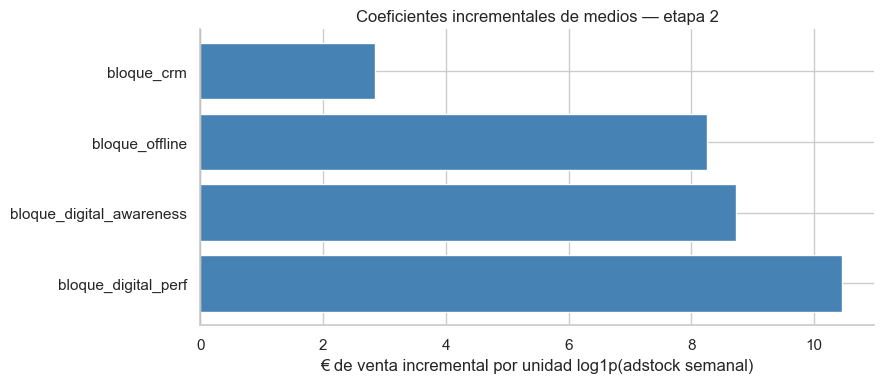

In [19]:
# Coeficientes del modelo final
base_model = fit_full['model_base']
media_model = fit_full['model_media']
base_scaler = fit_full['scaler_base']
media_scaler = fit_full['scaler_media']

coefs_base_df = pd.DataFrame({
    'feature': BASE_FEATURES,
    'coef_scaled': base_model.coef_,
    'coef_real':   base_model.coef_ / base_scaler.scale_
}).sort_values('coef_real', ascending=False)

coefs_media_df = pd.DataFrame({
    'feature': MEDIA_FEATURES,
    'coef_scaled': media_model.coef_,
    'coef_real':   media_model.coef_ / media_scaler.scale_
})
coefs_media_df['bloque_raw'] = coefs_media_df['feature'].str.replace('x_', '', regex=False)
coefs_media_df = coefs_media_df.sort_values('coef_real', ascending=False)

print("=== COEFICIENTES BASE ESTRUCTURAL ===")
display(coefs_base_df[['feature', 'coef_real']].round(4))

print("\n=== COEFICIENTES INCREMENTALES DE MEDIOS (escala log1p) ===")
display(coefs_media_df[['feature', 'bloque_raw', 'coef_real']].round(4))

fig, ax = plt.subplots(figsize=(9, 4))
colores = ['steelblue' if v > 0 else 'coral' for v in coefs_media_df['coef_real']]
ax.barh(coefs_media_df['bloque_raw'], coefs_media_df['coef_real'], color=colores)
ax.axvline(0, color='gray', linewidth=0.8)
ax.set_title('Coeficientes incrementales de medios — etapa 2')
ax.set_xlabel('€ de venta incremental por unidad log1p(adstock semanal)')
plt.tight_layout()
plt.show()


In [20]:
# Descomposición base vs incremental del modelo final
df_model['pred_base'] = base_pred_all
df_model['pred_media'] = media_pred_all
df_model['pred_total'] = y_pred_all

resumen_componentes = []
for anio in range(2020, 2025):
    df_a = df_model[df_model['fecha'].dt.year == anio].copy()
    resumen_componentes.append({
        'anio': anio,
        'ventas_reales': df_a[TARGET].sum(),
        'base_pred': df_a['pred_base'].sum(),
        'media_pred': df_a['pred_media'].sum(),
        'pred_total': df_a['pred_total'].sum()
    })

res_comp = pd.DataFrame(resumen_componentes)
display(res_comp.round(0))


,anio,ventas_reales,base_pred,media_pred,pred_total
0,2020,92255504.0,92477140.0,516047.0,92993187.0
1,2021,138016859.0,137938147.0,516679.0,138454826.0
2,2022,160920157.0,160854779.0,516916.0,161371695.0
3,2023,176267585.0,176282313.0,517074.0,176799387.0
4,2024,199097664.0,199005391.0,527127.0,199532518.0


In [21]:
# Guardado de artefactos para estrategia y app
coefs_base_df.to_csv(os.path.join(DATA_PROC, 'coeficientes_mmm_base.csv'), index=False)
coefs_media_df.to_csv(os.path.join(DATA_PROC, 'coeficientes_mmm_media.csv'), index=False)

with open(os.path.join(DATA_PROC, 'modelo_mmm_base.pkl'), 'wb') as f:
    pickle.dump(base_model, f)
with open(os.path.join(DATA_PROC, 'scaler_mmm_base.pkl'), 'wb') as f:
    pickle.dump(base_scaler, f)
with open(os.path.join(DATA_PROC, 'modelo_mmm_media.pkl'), 'wb') as f:
    pickle.dump(media_model, f)
with open(os.path.join(DATA_PROC, 'scaler_mmm_media.pkl'), 'wb') as f:
    pickle.dump(media_scaler, f)

pd.DataFrame({'feature': BASE_FEATURES}).to_csv(os.path.join(DATA_PROC, 'base_features_mmm.csv'), index=False)
pd.DataFrame({'feature': MEDIA_FEATURES}).to_csv(os.path.join(DATA_PROC, 'media_features_mmm.csv'), index=False)

betas_bloques = coefs_media_df[['bloque_raw', 'coef_real']].rename(
    columns={'bloque_raw': 'bloque', 'coef_real': 'beta_real'}
).copy()
betas_bloques['positivo'] = betas_bloques['beta_real'] > 0
betas_bloques['transformacion'] = 'log1p(adstock_semanal)'
betas_bloques.to_csv(os.path.join(DATA_PROC, 'betas_bloques.csv'), index=False)

print("✓ Modelo guardado")
print(f"\nResumen final del modelo MMM (2 etapas):")
print(f"  MAPE CV medio total:              {np.mean(mapes):.2f}%")
if len(mapes_ex_covid) > 0:
    print(f"  MAPE CV medio ex-COVID:           {np.mean(mapes_ex_covid):.2f}%")
print(f"  R² CV medio total:                {np.mean(r2s):.4f}")
print(f"  MAPE holdout 2024:                {mape_holdout:.2f}%")
print(f"  R² holdout 2024:                  {r2_holdout:.4f}")
print(f"  MAPE in-sample (referencia):      {mape_total:.2f}%")
print(f"  R² in-sample (referencia):        {r2_total:.4f}")
print(f"  Base estructural anual estimada:  {df_model['pred_base'].sum() / len(df_model) * 52:,.0f} €")
print(f"\nCoeficientes incrementales de bloques (escala log1p):")
for _, row in betas_bloques.iterrows():
    signo = '✓' if row['positivo'] else '✗'
    print(f"  {signo} {row['bloque']:<30} β={row['beta_real']:+.4f}")


✓ Modelo guardado

Resumen final del modelo MMM (2 etapas):
  MAPE CV medio total:              10.28%
  MAPE CV medio ex-COVID:           5.57%
  R² CV medio total:                -1.0518
  MAPE holdout 2024:                18.11%
  R² holdout 2024:                  -0.3089
  MAPE in-sample (referencia):      0.86%
  R² in-sample (referencia):        0.9973
  Base estructural anual estimada:  152,724,153 €

Coeficientes incrementales de bloques (escala log1p):
  ✓ bloque_digital_perf            β=+10.4524
  ✓ bloque_digital_awareness       β=+8.7200
  ✓ bloque_offline                 β=+8.2534
  ✓ bloque_crm                     β=+2.8544
